### ENSIMAG – Grenoble INP – UGA - Academic year 2024-2025
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Alexandre Wendling -- `alexandre.wendling@univ-grenoble-alpes.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods (25 points)

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1 (9 points)

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

In [159]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import multivariate_normal
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier


In [160]:
#STEP1
p=0.30
epsilon=2
N1=50
N2=10**3
#Sample U1 et U2
U1=np.random.rand(N1)
U2=np.random.rand(N2)


B1=[]
B2=[]

#Initialize the train and test datasets
X1 = np.zeros(shape=(N1,2))
X2 = np.zeros(shape=(N2,2))

#Parameters of the normal distributions
m0 = [0,0]
m1 = [epsilon,0]
cov0 = np.array([[0.5,0],[0,0.5]])
cov1 = np.array([[0.4,0],[0,0.4]])

#Sample B1 then X1
for i in range(N1) :
    if (U1[i]<p):
        B1.append(1)
        X1[i]= np.random.multivariate_normal(m1,cov1)
        
    else:
        B1.append(0)
        X1[i]= np.random.multivariate_normal(m0,cov0)

#Sample B2 then X2      
for i in range(N2) :
    if (U2[i]<p):
        B2.append(1)
        X2[i]= np.random.multivariate_normal(m1,cov1)
    else:
        B2.append(0)
        X2[i]= np.random.multivariate_normal(m0,cov0)

# Converting B1 and B2 to numpy arrays for easier indexing
B1 = np.array(B1)
B2 = np.array(B2)

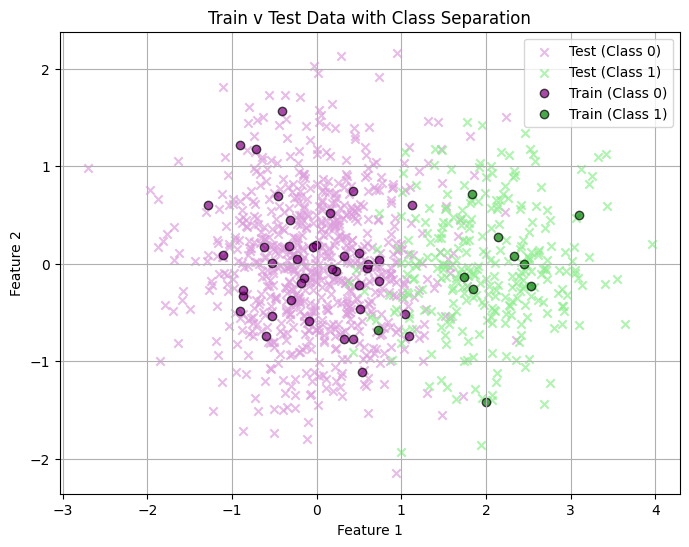

In [161]:
# Visualization 
plt.figure(figsize=(8, 6))


# Test (X2): Class 0 (purple crosses) and Class 1 (green crosses)
plt.scatter(X2[B2 == 0, 0], X2[B2 == 0, 1], 
            c='plum', marker='x', label='Test (Class 0)', alpha=0.7)

plt.scatter(X2[B2 == 1, 0], X2[B2 == 1, 1], 
            c='lightgreen', marker='x', label='Test (Class 1)', alpha=0.7)


# Train (X1): Class 0 (purple circles) and Class 1 (green circles)
plt.scatter(X1[B1 == 0, 0], X1[B1 == 0, 1], 
            c='purple',edgecolor="black", marker='o', label='Train (Class 0)', alpha=0.7)

plt.scatter(X1[B1 == 1, 0], X1[B1 == 1, 1], 
            c='green', edgecolor="black", marker='o', label='Train (Class 1)', alpha=0.7)


plt.title("Train v Test Data with Class Separation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

# Classifieur de Bayes Optimal?

#### Modèle Gaussien à Deux Classes

#### Paramètres
- **Classe 0** : 
  - Moyenne : $\mathbf{\mu}_0 = [0, 0]^T$
  - Covariance : $\mathbf{\Sigma}_0 = \begin{bmatrix} 0.5 & 0 \\ 0 & 0.5 \end{bmatrix}$
- **Classe 1** :
  - Moyenne : $\mathbf{\mu}_1 = [\epsilon, 0]^T$ (avec $\epsilon = 2$)
  - Covariance : $\mathbf{\Sigma}_1 = \begin{bmatrix} 0.4 & 0 \\ 0 & 0.4 \end{bmatrix}$
- **A Priori** : $P(Y=1) = p = 0.3$



Le classifieur attribue la classe avec la **probabilité a posteriori** maximale :
$$
h^*(\mathbf{x}) = \begin{cases} 
1 & \text{si } \frac{P(Y=1|\mathbf{x})}{P(Y=0|\mathbf{x})} \geq 1 \\
0 & \text{sinon}
\end{cases}
$$

#### Le rapport de Vraisemblance est comme suit:
$$
\frac{P(Y=1|\mathbf{x})}{P(Y=0|\mathbf{x})} = \frac{p \cdot f_1(\mathbf{x})}{(1-p) \cdot f_0(\mathbf{x})}
$$
où $f_k(\mathbf{x})$ est la densité Gaussienne :
$$
f_k(\mathbf{x}) = \frac{1}{2\pi |\mathbf{\Sigma}_k|^{1/2}} \exp\left(-\frac{1}{2} (\mathbf{x}-\mathbf{\mu}_k)^T \mathbf{\Sigma}_k^{-1} (\mathbf{x}-\mathbf{\mu}_k)\right)
$$

## Frontière de Décision ?

#### La frontière est définie par l'équation:

$$
\frac{p \cdot f_1(\mathbf{x})}{(1-p) \cdot f_0(\mathbf{x})} = 1
$$

En prenant le logarithme :
$$
\log\left(\frac{p}{1-p}\right) + \underbrace{\log f_1(\mathbf{x}) - \log f_0(\mathbf{x})}_{\text{Terme quadratique}} = 0
$$

#### Développement Complet
$$
-\frac{1}{2} \left( (\mathbf{x}-\mathbf{\mu}_1)^T \mathbf{\Sigma}_1^{-1} (\mathbf{x}-\mathbf{\mu}_1) - (\mathbf{x}-\mathbf{\mu}_0)^T \mathbf{\Sigma}_0^{-1} (\mathbf{x}-\mathbf{\mu}_0) \right) + \log\left(\frac{p}{1-p}\right) - \frac{1}{2} \log\left(\frac{|\mathbf{\Sigma}_1|}{|\mathbf{\Sigma}_0|}\right) = 0
$$


## Cas Particuliers

#### Covariances Égales ($\mathbf{\Sigma}_0 = \mathbf{\Sigma}_1$)
La frontière devient **linéaire** :
$$
(\mathbf{\mu}_1 - \mathbf{\mu}_0)^T \mathbf{\Sigma}^{-1} \mathbf{x} + \text{constante} = 0
$$


Avec $\mathbf{\Sigma}_0 \neq \mathbf{\Sigma}_1$, la frontière est une **quadrique** (hyperbole ici).

---


**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [162]:

class GaussianBayesClassifier(ClassifierMixin,BaseEstimator):
    def __init__(self, p=0.3, mean0=None, mean1=None, cov0=None, cov1=None):
        self.p = p          
        self.mean0 = mean0  
        self.mean1 = mean1 
        self.cov0 = cov0    
        self.cov1 = cov1    

    def fit(self, X, y):
        X, y = validate_data(self, X, y)
        if self.mean0 is None:
            self.mean0 = X[y == 0].mean(axis=0)  #  mean of class 0
        if self.mean1 is None:
            self.mean1 = X[y == 1].mean(axis=0)  #  mean of class 1
        if self.cov0 is None:
            self.cov0 = np.cov(X[y == 0].T)     #  covariance of class 0
        if self.cov1 is None:
            self.cov1 = np.cov(X[y == 1].T)     #  covariance of class 1
        return self

    def predict_proba(self, X):
        # likelihoods
        prob0 = (1 - self.p) * multivariate_normal.pdf(X, self.mean0, self.cov0)
        prob1 = self.p * multivariate_normal.pdf(X, self.mean1, self.cov1)
        # Normalizing for posteriori
        total = prob0 + prob1
        return np.vstack([prob0 / total, prob1 / total]).T
        
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [163]:
p=0.30
epsilon=2
N_new=10**4
U_new=np.random.rand(N_new)
B_new=[]

X_new = np.zeros(shape=(N_new,2))

#Sample B1 then X1
for i in range(N_new) :
    if (U_new[i]<p):
        B_new.append(1)
        X_new[i]= np.random.multivariate_normal(m1,cov1)
        
    else:
        B_new.append(0)
        X_new[i]= np.random.multivariate_normal(m0,cov0)


# Initializing classifier with our parameters..

bayes = GaussianBayesClassifier(
    p=0.3, 
    mean0=m0, 
    mean1=m1, 
    cov0=cov0, 
    cov1=cov1
)

# Prediction on new data! no need to fit since we already know what the real parameters are

score = bayes.score(X_new,B_new)
error_rate = 1 - score
print(f"Bayes error rate: {error_rate:.3f}")

Bayes error rate: 0.061


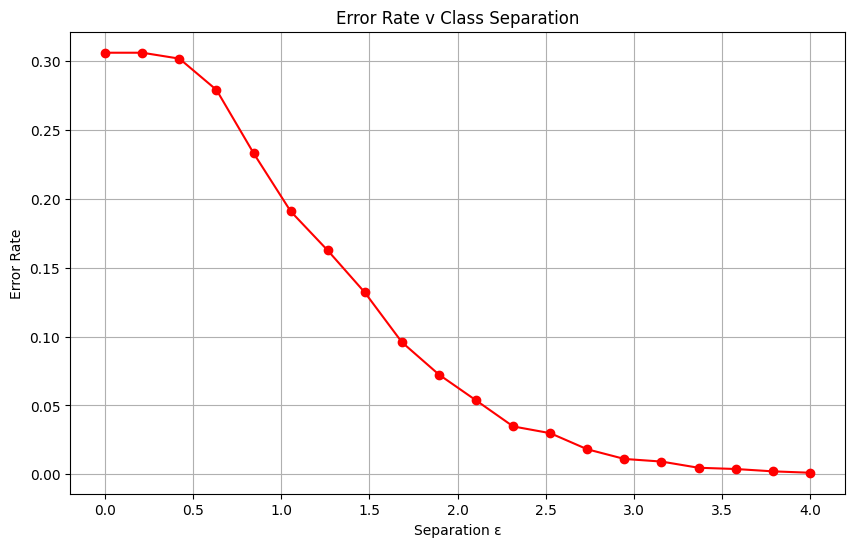

In [164]:
#Initializing epsilons ranging from 0 to 4 

epsilons = np.linspace(0, 4, 20)
error_rates = []

# let's generate a dataset for each epsilon..

for eps in epsilons:
    m1_new = [eps, 0]
    X_new = np.zeros_like(X_new)
    for i in range(N_new):
        if U_new[i] < p:
            X_new[i] = np.random.multivariate_normal(m1_new, cov1)
        else:
            X_new[i] = np.random.multivariate_normal(m0, cov0)
    
    # Bayes error
    bayes.mean1 = m1_new
    score = bayes.score(X_new,B_new)
    error_rates.append(1-score)

# Plot of Bayes Error rate based on different choices of ε!

plt.figure(figsize=(10, 6))
plt.plot(epsilons, error_rates, marker='o', linestyle='-', color='r')
plt.xlabel("Separation ε")
plt.ylabel("Error Rate")
plt.title("Error Rate v Class Separation")
plt.grid(True)
plt.show()

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

#### The most adequate classifier for the Gaussian mixture model is the Quadratic Discriminant Analysis (QDA), with Linear Discriminant Analysis (LDA) being a close second if covariances are assumed equal. 

---
#### Here is why based on the assumptions made in the course!

- Class-conditional distributions are Gaussian.

- Each class has its own covariance matrix.

#### Why QDA?

- Our data is generated from two Gaussians with different covariances.
- QDA’s decision boundary is quadratic, perfectly capturing the true Bayes classifier’s boundary in this case.
> It is optimal since the true data-generating process matches assumptions.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [167]:
#Classifiers
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()
logistic = LogisticRegression(max_iter=1000) 

# Train on train dataset (X1,B1)
lda.fit(X1, B1)
qda.fit(X1, B1)
logistic.fit(X1, B1)

# Predictions
y_pred_lda = lda.predict(X2)
y_pred_qda = qda.predict(X2)
y_pred_logistic = logistic.predict(X2)

# Error rates
error_lda = 1 - accuracy_score(B2, y_pred_lda)
error_qda = 1 - accuracy_score(B2, y_pred_qda)
error_logistic = 1 - accuracy_score(B2, y_pred_logistic)

In [168]:
print(f"LDA Test Error: {error_lda:.4f}")
print(f"QDA Test Error: {error_qda:.4f}")
print(f"Logistic Test Error: {error_logistic:.4f}")

LDA Test Error: 0.0710
QDA Test Error: 0.0730
Logistic Test Error: 0.0790


In [169]:
# Initializing classifier with our parameters..

bayes = GaussianBayesClassifier(
    p=0.3, 
    mean0=m0, 
    mean1=m1, 
    cov0=cov0, 
    cov1=cov1
)

# Prediction on test data! 

score = bayes.score(X2,B2)
error_rate = 1 - score
print(f"Bayes Test Error: {error_rate:.4f}")

Bayes Test Error: 0.0710


**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [170]:
p_new=0.7
epsilon_new=0.5
N_new=10**3
U_new=np.random.rand(N_new)
B_new=[]

m1_new = [epsilon,0]

X_new = np.zeros(shape=(N_new,2))

#Sample 
for i in range(N_new) :
    if (U_new[i]<p):
        B_new.append(1)
        X_new[i]= np.random.multivariate_normal(m1_new,cov1)
        
    else:
        B_new.append(0)
        X_new[i]= np.random.multivariate_normal(m0,cov0)

B_new=np.array(B_new)

In [171]:
# Predictions
y_pred_lda = lda.predict(X_new)
y_pred_qda = qda.predict(X_new)
y_pred_logistic = logistic.predict(X_new)

# Error rates
error_lda = 1 - accuracy_score(B_new, y_pred_lda)
error_qda = 1 - accuracy_score(B_new, y_pred_qda)
error_logistic = 1 - accuracy_score(B_new, y_pred_logistic)

In [172]:
print(f"LDA Test Error: {error_lda:.4f}")
print(f"QDA Test Error: {error_qda:.4f}")
print(f"Logistic Test Error: {error_logistic:.4f}")

LDA Test Error: 0.0660
QDA Test Error: 0.0670
Logistic Test Error: 0.0670


We trained the models on data sets with larget separation between the gaussians (epsilon).  
We also assumed a class probability for class 1 of (p = 0.3) favoring class 0, but test data now has 70% of class 1.This shifts the decision boundary. Though, the error rates are quite low, indicating that the classifiers are doing well in predicting the new data. 

There is a slight improvement in the error rates for all classifiers on the new test set compared to the first test set.Given the same classifiers were used, we may say they are better aligned with the new data's distribution, leading to the observed improvement in test error.

## ▶️ Part 2 (8 points)

In this part, we will consider a simulated benchmark similar to that from [Section 4.5.2 in James et al](https://www.statlearning.com/) presented and discussed in class. Our benchmark will compare the performance of four classifiers under three different scenarios.

### -- Scenario 1
The observations for this scenario are generated as per:

$$
\{(\mathbf{x}_i, y_i)\}_{i = 1}^{2N} = \{(\mathbf{x}_i, 0)\}_{i = 1}^{N} \cup \{(\mathbf{x}_i, 1)\}_{i = 1}^{N}
$$
with
$$
\mathbf{x}_i | y_i = 0 \sim \mathcal{N}(\mathbf{\mu}_0, \mathbf{\Sigma}_0) \quad \text{with} \quad \mathbf{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_0 = \left[\begin{array}{cc}1 & 0 \\ 0 & 2\end{array}\right]
$$
and
$$
\mathbf{x}_i | y_i = 1 \sim \mathcal{N}(\mathbf{\mu}_1, \mathbf{\Sigma}_1) \quad \text{with} \quad \mathbf{\mu}_1 = \left[\begin{array}{c}1 \\ 1\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_1 = \left[\begin{array}{cc}1 & 0 \\ 0 & 2\end{array}\right]~.
$$

The training set always have $N=20$ and the test set $N=5000$. 

**(a)** Using `sklearn`, compare the performances of LDA, logistic regression, Gaussian naive Bayes, and QDA in this scenario. For this, you should generate 100 pairs of training-test datasets and evaluate the test errors for each of the classifiers. Use `matplotlib.pyplot.boxplot` to display the results for each of the classifiers along the different realizations. Explain the differences of the performances in terms of the assumptions of each classifier and the structure of the data generating mechanism.

#### a) As the model is suited to the assumed LDA model ( as we have gaussian distributions w/ same correlation matrix) 
> we can expect LDA to perform well

> So obviously it's very possible that QDA isn't gonna perform as well as LDA.

#### as we know stuff about the data,
> KNN isn't really gonna be the right choice .

#### as the boundary it provides us with is linear
> Logistic regression might be also performative.

#### Knowing that we made the assumption of independent observations
> Naiive Bayes may perform better than others 

### a) Generating the train and test datasets..

In [55]:
def generateData(p,N,m0,m1,cov0,cov1):

    #Sample U
    U=np.random.rand(N)
    
    B=[]

    #Initialize the dataset
    X = np.zeros(shape=(N,2))


    #Sample B then X
    for i in range(N) :
        if (U[i]<p):
            B.append(1)
            X[i]= np.random.multivariate_normal(m1,cov1)
        
        else:
            B.append(0)
            X[i]= np.random.multivariate_normal(m0,cov0)

    # Converting B
    B = np.array(B)
    return X,B

In [57]:
N_train = 20
N_test = 5000
n=100 #how many datasets? 

#Parameters of the normal distributions
m0 = [0,0]
m1 = [1,1]
cov = np.array([[1,0],[0,2]])


# Initializing the sets
Xs_train = np.zeros((n, N_train, 2))
Bs_train = np.zeros((n, N_train))
Xs_test = np.zeros((n, N_test, 2)) 
Bs_test = np.zeros((n, N_test))



for i in range(n):
    X_train, B_train = generateData(0.5, N_train, m0, m1, cov, cov)
    Xs_train[i] = X_train
    Bs_train[i] = B_train
    
    X_test, B_test = generateData(0.5, N_test, m0, m1, cov, cov)
    Xs_test[i] = X_test
    Bs_test[i] = B_test

In [58]:
Xs_train.shape

(100, 20, 2)

In [59]:
Xs_test.shape

(100, 5000, 2)

In [63]:
Bs_train.shape

(100, 20)

In [62]:
Bs_test.shape

(100, 5000)

> ### Let's take a look at some of our datasets!

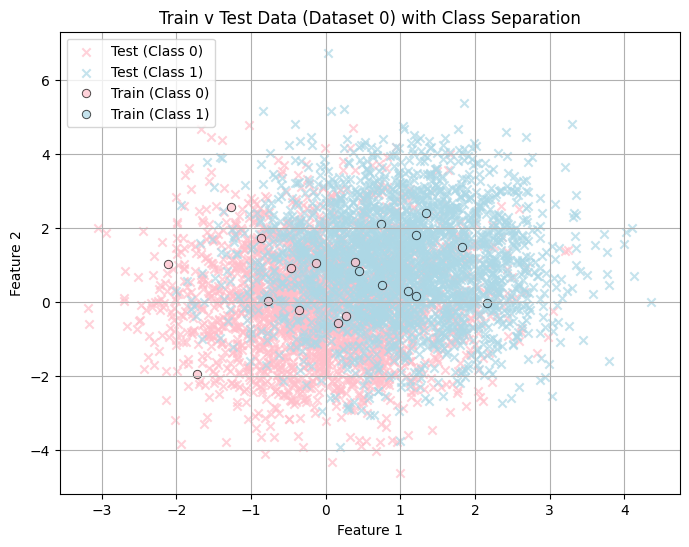

In [111]:
index = 0

# Visualization 
plt.figure(figsize=(8, 6))

# Test (X2): Class 0 (purple crosses) and Class 1 (green crosses)
plt.scatter(Xs_test[index][Bs_test[index] == 0, 0], Xs_test[index][Bs_test[index] == 0, 1], 
            c='pink', marker='x', label='Test (Class 0)', alpha=0.7)

plt.scatter(Xs_test[index][Bs_test[index] == 1, 0], Xs_test[index][Bs_test[index] == 1, 1], 
            c='lightblue', marker='x', label='Test (Class 1)', alpha=0.7)

# Train (X1): Class 0 (purple circles) and Class 1 (green circles)
plt.scatter(Xs_train[index][Bs_train[index] == 0, 0], Xs_train[index][Bs_train[index] == 0, 1], 
            c='pink',edgecolor='black', marker='o', label='Train (Class 0)', alpha=0.7,linewidths=0.7)

plt.scatter(Xs_train[index][Bs_train[index] == 1, 0], Xs_train[index][Bs_train[index] == 1, 1], 
            c='lightblue',edgecolor='black', marker='o', label='Train (Class 1)', alpha=0.7,linewidths=0.7)



plt.title(f"Train v Test Data (Dataset {index}) with Class Separation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

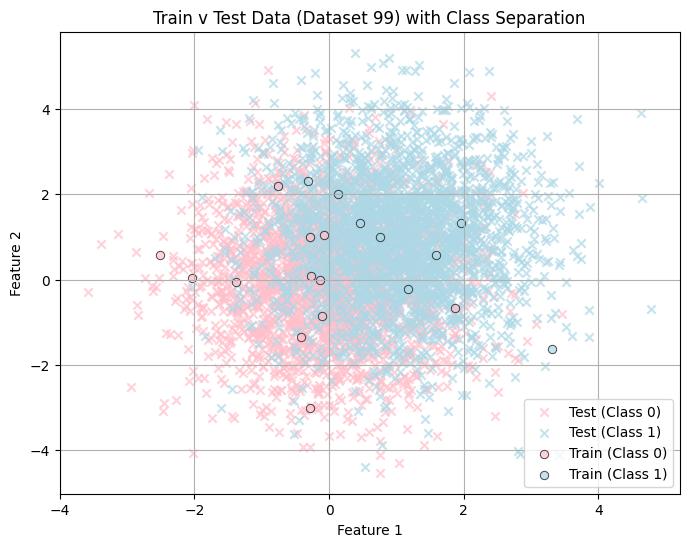

In [120]:
index = 99

# Visualization 
plt.figure(figsize=(8, 6))

# Test (X2): Class 0 (purple crosses) and Class 1 (green crosses)
plt.scatter(Xs_test[index][Bs_test[index] == 0, 0], Xs_test[index][Bs_test[index] == 0, 1], 
            c='pink', marker='x', label='Test (Class 0)', alpha=0.7)

plt.scatter(Xs_test[index][Bs_test[index] == 1, 0], Xs_test[index][Bs_test[index] == 1, 1], 
            c='lightblue', marker='x', label='Test (Class 1)', alpha=0.7)

# Train (X1): Class 0 (purple circles) and Class 1 (green circles)
plt.scatter(Xs_train[index][Bs_train[index] == 0, 0], Xs_train[index][Bs_train[index] == 0, 1], 
            c='pink',edgecolor='black', marker='o', label='Train (Class 0)', alpha=0.7,linewidths=0.7)

plt.scatter(Xs_train[index][Bs_train[index] == 1, 0], Xs_train[index][Bs_train[index] == 1, 1], 
            c='lightblue',edgecolor='black', marker='o', label='Train (Class 1)', alpha=0.7,linewidths=0.7)



plt.title(f"Train v Test Data (Dataset {index}) with Class Separation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

### Applying the different models ?

In [101]:
n=100

errors_lda = np.zeros(n)
errors_qda = np.zeros(n)
errors_logistic = np.zeros(n)
errors_gnb = np.zeros(n)


for i in range(n):

    #Classifiers
    lda = LinearDiscriminantAnalysis()
    qda = QuadraticDiscriminantAnalysis()
    logistic = LogisticRegression(max_iter=1000)
    gnb = GaussianNB()

    # Train on train dataset (X1,B1)
    lda.fit(Xs_train[i], Bs_train[i])
    qda.fit(Xs_train[i], Bs_train[i])
    logistic.fit(Xs_train[i], Bs_train[i])
    gnb.fit(Xs_train[i], Bs_train[i])
    
    # Predictions
    prediction_lda = lda.predict(Xs_test[i])
    prediction_qda = qda.predict(Xs_test[i])
    prediction_logistic = logistic.predict(Xs_test[i])
    prediction_gnb = gnb.predict(Xs_test[i])
    
    # Error rates
    errors_lda[i] = 1 - accuracy_score(Bs_test[i], prediction_lda)
    errors_qda[i] = 1 - accuracy_score(Bs_test[i], prediction_qda)
    errors_logistic[i] = 1 - accuracy_score(Bs_test[i], prediction_logistic)
    errors_gnb[i] = 1 - accuracy_score(Bs_test[i], prediction_gnb)
    
        

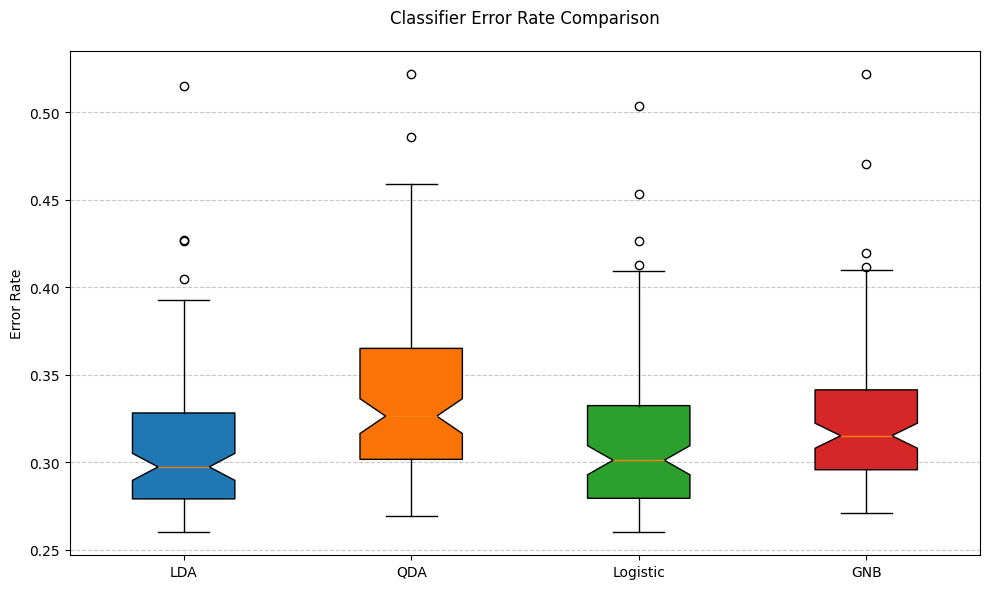

In [116]:
error_data = [errors_lda, errors_qda, errors_logistic, errors_gnb]
classifier_names = ['LDA', 'QDA', 'Logistic', 'GNB'] 

# Create boxplot 
plt.figure(figsize=(10, 6))
box = plt.boxplot(
    error_data,
    notch=True,
    patch_artist=True,  
    tick_labels=classifier_names  
)

colors = ['#1f77b4', '#F97306', '#2ca02c', '#d62728']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Classifier Error Rate Comparison', pad=20)
plt.ylabel('Error Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [119]:
# Counting outliers

outlier_counts = {
    'Classifier': classifier_names,
    'Outliers': [len(box['fliers'][i].get_data()[1]) for i in range(4)]
}
print(pd.DataFrame(outlier_counts))

  Classifier  Outliers
0        LDA         4
1        QDA         2
2   Logistic         4
3        GNB         4


### <span style='color:purple'> For all the following 3 scenarios the setup of 20 samples for training and 5000 for test, favors classifiers that are low-variance, those that don't require a lot of parameters to estimate. High-variance classifiers will struggle here as : </span>

    . They overfit the small training data
    . And generalize poorly to the large test set
----
>  <span style='color:navy'> LDA </span>
>  is very stable even with few data points as it only estimates one shared covariance matrix leading to a low variance.

> Despite the training set being of a small size (also compared to the testing set), the <span style='color:green'> Logistic Regression </span> learns a linear boundary using simple parameter estimation and it's not a generative approach so there is no estimation of distributions. With proper regularization it's handling small sample sizes fairly well. 

> The <span style='color:orange'> QDA </span> must estimate a full covariance matrix for each class , knowing our training dataset is only 20 samples this is definitely leading to unstable estimates. Which makes sense as even with the Gaussian assumption being held, QDA can't make good use of it without enough data. As a result we get an overfitting problem leading to worse generalization so finally a poor performance. 

> <span style='color:red'> GNB </span>, with low parameters leading to a low-variance, it has a bad 

### <span style='color:purple'> Based on the assumptions made: </span> 

#### LDA has the lowest median error rate and a relatively tight interquartile range (IQR) which is expected knowing the assumptions made by the model on the data that are actually held.


> ### <span style='color:navy'> As Linear Discriminant Analysis </span>

    Assumes multivariate normality of features within each class and equal covariance matrices across classes.

    That the decision boundaries are linear.


#### Logistic Regression performs comparably to LDA with slightly more variability.. explained by the assumption of a linear decision boundary ( As we've verified in class despite it being non-linear in the parameters )


> ### <span style='color:green'> The Logistic Regression </span>

    Makes no assumption of normality or equal variances, but assumes a linear decision boundary in the transformed log-odds space.

    We've also seen that it tends to perform similarly to LDA when assumptions for LDA hold, and it's more robust when they don't, Noting that when the data is truly Gaussian in each class, the classifiers are equivalent  


#### QDA has the highest median error rate and the widest spread, since it's designed to fit a more flexible classifier.


> ### <span style='color:orange'> for Quadratic Discriminant Analysis </span>

    Also assumes multivariate normality, but allows for different covariance matrices, Leading to quadratic decision boundaries.

    QDA performs better when classes differ not only in means but also in variance structure.

    And it's more flexible than LDA but needs more data to estimate the covariance matrices in a reliable way as we can face the  risk of overfitting if data is limited (for it estimates more parameters than LDA)..


#### GNB shows lower median performance to QDA but still performed better than the QDA thanks to the independence assumption that is respected.


> ### <span style='color:red'> Gaussian Naive Bayes </span>

    Gnb assumes independence between features (which is a very strong assumption we usually find ourselves making when working with a lot of predictors).

    it Also assumes normal distribution of features for each class.

    it could perform surprisingly well even when independence assumption is violated, but tends to be less accurate if feature dependencies are strong ( as we're not necessarily expecting the assumption to be true)



---


> We can clearly infer that our data is well conform to LDA’s assumptions ( normality and same covariance), which is why LDA performs best. QDA underperforms which is so likely due to overfitting and extra complexity that isn’t justified by the data. Logistic Regression is competitive, which suggests that the linear boundary assumption is still reasonable, even without the strict distributional assumptions. And GNB shows a little higher variance in performance than LDA but still is way better than QDA.

#### So errors are as predicted:
> Results from LDA are the lowest.  Logistic Regression also performed well
> followed by GNB and then QDA.

### -- Scenario 2
The observations for this scenario are generated as per:

$$
\{(\mathbf{x}_i, y_i)\}_{i = 1}^{2N} = \{(\mathbf{x}_i, 0)\}_{i = 1}^{N} \cup \{(\mathbf{x}_i, 1)\}_{i = 1}^{N}
$$
with
$$
\mathbf{x}_i | y_i = 0 \sim \mathcal{N}(\mathbf{\mu}_0, \mathbf{\Sigma}_0) \quad \text{with} \quad \mathbf{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_0 = \left[\begin{array}{cc}1 & -0.7 \\ -0.7 & 2\end{array}\right]
$$
and
$$
\mathbf{x}_i | y_i = 1 \sim \mathcal{N}(\mathbf{\mu}_1, \mathbf{\Sigma}_1) \quad \text{with} \quad \mathbf{\mu}_1 = \left[\begin{array}{c}1 \\ 1\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_1 = \left[\begin{array}{cc}1 & -0.7 \\ -0.7 & 2\end{array}\right]~.
$$

The training set always have $N=20$ and the test set $N=5000$. 

**(b)** Perform the same comparison as done for Scenario 1.


In [121]:
N_train = 20
N_test = 5000
n=100 #how many datasets? 

#Parameters of the normal distributions
m0 = [0,0]
m1 = [1,1]
cov = np.array([[1,-0.7],[-0.7,2]])


# Initializing the sets
Xs_train = np.zeros((n, N_train, 2))
Bs_train = np.zeros((n, N_train))
Xs_test = np.zeros((n, N_test, 2)) 
Bs_test = np.zeros((n, N_test))



for i in range(n):
    X_train, B_train = generateData(0.5, N_train, m0, m1, cov, cov)
    Xs_train[i] = X_train
    Bs_train[i] = B_train
    
    X_test, B_test = generateData(0.5, N_test, m0, m1, cov, cov)
    Xs_test[i] = X_test
    Bs_test[i] = B_test

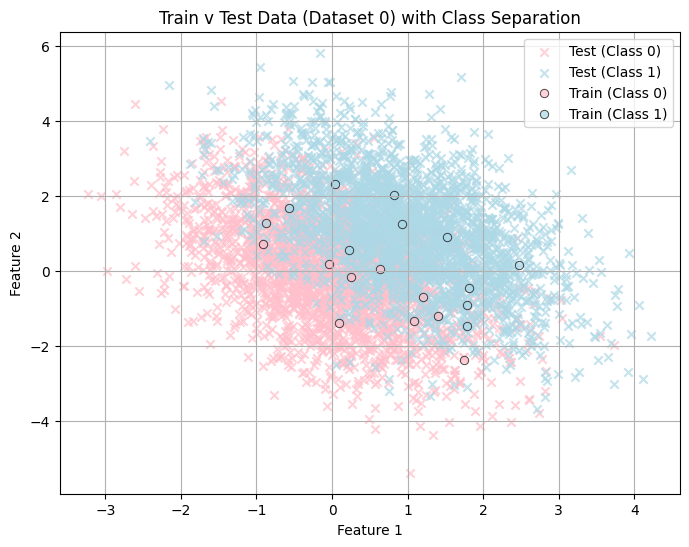

In [122]:
index = 0

# Visualization 
plt.figure(figsize=(8, 6))

# Test (X2): Class 0 (purple crosses) and Class 1 (green crosses)
plt.scatter(Xs_test[index][Bs_test[index] == 0, 0], Xs_test[index][Bs_test[index] == 0, 1], 
            c='pink', marker='x', label='Test (Class 0)', alpha=0.7)

plt.scatter(Xs_test[index][Bs_test[index] == 1, 0], Xs_test[index][Bs_test[index] == 1, 1], 
            c='lightblue', marker='x', label='Test (Class 1)', alpha=0.7)

# Train (X1): Class 0 (purple circles) and Class 1 (green circles)
plt.scatter(Xs_train[index][Bs_train[index] == 0, 0], Xs_train[index][Bs_train[index] == 0, 1], 
            c='pink',edgecolor='black', marker='o', label='Train (Class 0)', alpha=0.7,linewidths=0.7)

plt.scatter(Xs_train[index][Bs_train[index] == 1, 0], Xs_train[index][Bs_train[index] == 1, 1], 
            c='lightblue',edgecolor='black', marker='o', label='Train (Class 1)', alpha=0.7,linewidths=0.7)



plt.title(f"Train v Test Data (Dataset {index}) with Class Separation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

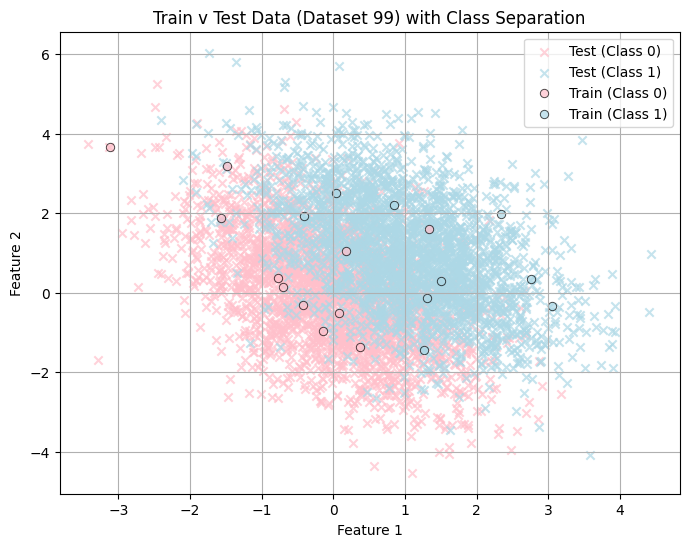

In [123]:
index = 99

# Visualization 
plt.figure(figsize=(8, 6))

# Test (X2): Class 0 (purple crosses) and Class 1 (green crosses)
plt.scatter(Xs_test[index][Bs_test[index] == 0, 0], Xs_test[index][Bs_test[index] == 0, 1], 
            c='pink', marker='x', label='Test (Class 0)', alpha=0.7)

plt.scatter(Xs_test[index][Bs_test[index] == 1, 0], Xs_test[index][Bs_test[index] == 1, 1], 
            c='lightblue', marker='x', label='Test (Class 1)', alpha=0.7)

# Train (X1): Class 0 (purple circles) and Class 1 (green circles)
plt.scatter(Xs_train[index][Bs_train[index] == 0, 0], Xs_train[index][Bs_train[index] == 0, 1], 
            c='pink',edgecolor='black', marker='o', label='Train (Class 0)', alpha=0.7,linewidths=0.7)

plt.scatter(Xs_train[index][Bs_train[index] == 1, 0], Xs_train[index][Bs_train[index] == 1, 1], 
            c='lightblue',edgecolor='black', marker='o', label='Train (Class 1)', alpha=0.7,linewidths=0.7)



plt.title(f"Train v Test Data (Dataset {index}) with Class Separation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

### Performance of the models!

In [124]:
n=100

errors_lda = np.zeros(n)
errors_qda = np.zeros(n)
errors_logistic = np.zeros(n)
errors_gnb = np.zeros(n)


for i in range(n):

    #Classifiers
    lda = LinearDiscriminantAnalysis()
    qda = QuadraticDiscriminantAnalysis()
    logistic = LogisticRegression(max_iter=1000)
    gnb = GaussianNB()

    # Train on train dataset
    lda.fit(Xs_train[i], Bs_train[i])
    qda.fit(Xs_train[i], Bs_train[i])
    logistic.fit(Xs_train[i], Bs_train[i])
    gnb.fit(Xs_train[i], Bs_train[i])
    
    # Predictions
    prediction_lda = lda.predict(Xs_test[i])
    prediction_qda = qda.predict(Xs_test[i])
    prediction_logistic = logistic.predict(Xs_test[i])
    prediction_gnb = gnb.predict(Xs_test[i])
    
    # Error rates
    errors_lda[i] = 1 - accuracy_score(Bs_test[i], prediction_lda)
    errors_qda[i] = 1 - accuracy_score(Bs_test[i], prediction_qda)
    errors_logistic[i] = 1 - accuracy_score(Bs_test[i], prediction_logistic)
    errors_gnb[i] = 1 - accuracy_score(Bs_test[i], prediction_gnb)
    

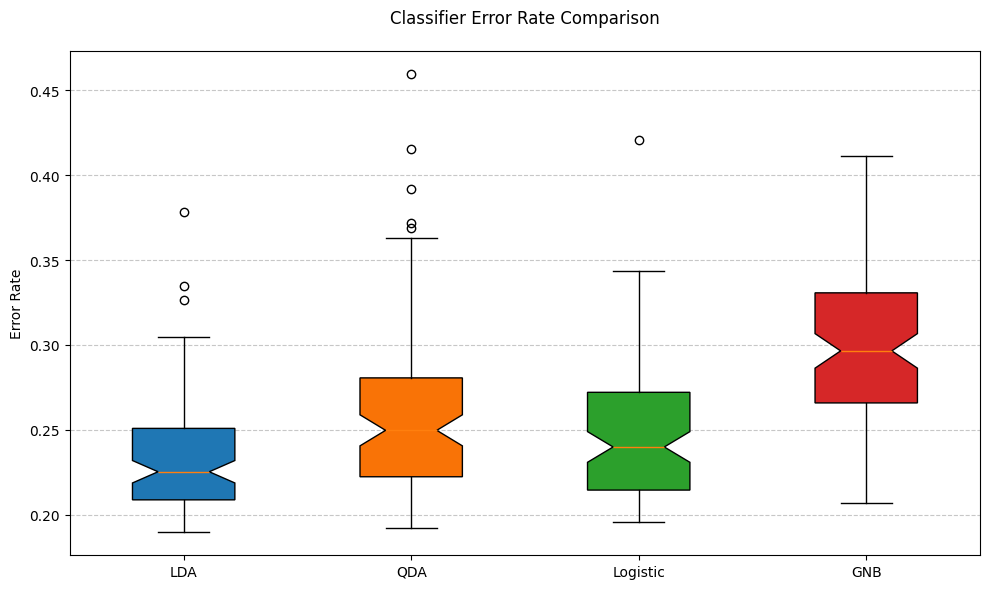

In [125]:
error_data = [errors_lda, errors_qda, errors_logistic, errors_gnb]
classifier_names = ['LDA', 'QDA', 'Logistic', 'GNB'] 

# Create boxplot 
plt.figure(figsize=(10, 6))
box = plt.boxplot(
    error_data,
    notch=True,
    patch_artist=True,  
    tick_labels=classifier_names 
)

colors = ['#1f77b4', '#F97306', '#2ca02c', '#d62728']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Classifier Error Rate Comparison', pad=20)
plt.ylabel('Error Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

That means all Gaussian-based classifiers (LDA, QDA, GNB) are working in a setting where their distributional assumptions hold true, narrowing down the differences to covariance structure, feature independence, and sample size.

### <span style='color:purple'> Based on the assumptions already mentioned above: </span> 
>  <span style='color:navy'> Linear Discriminant Analysis </span>

LDA has the best performance in our boxplot, for the data is reasonably Gaussian, and the covariances across classes are similar. Also it handles correlated features well due to shared covariance structure and is performing well as the class separation is linear.


>  <span style='color:green'> Logistic Regression </span>

Performs comparably to LDA, the decision boundary between classes is for real linear. Logistic regression is also less sensitive to outliers than LDA.

> <span style='color:orange'> Quadratic Discriminant Analysis </span>

Also assuming multivariate normality, but allowing different covariance matrices, Leading to quadratic decision boundaries, it performs better when classes differ not only in means but also in variance structure -> leading to results that are slightly worse than LDA. Which is due to the fact that the extra flexibility of QDA (non-linear boundaries) was not very beneficial here. 
    
The data also doesn’t have enough samples per class to reliably estimate class-specific covariances, increasing variance and risk of overfitting problem.


>  <span style='color:red'> Gaussian Naive Bayes </span>

Gnb assumes independence between features which we don't hold in this second scenario as the covariance matrix is no longer diagonal. As a result the GNB is underfitting by using a model that's too simple to explain the data.

So although it has a low variance thanks to the simplification of the model by making the independence assumtion, it's bias is now higher.

---


> QDA underperforms LDA due to the possible overfitting and extra complexity that isn’t justified by the data. And GNB shows a way higher variance in performance than all of the others due to the assumption we dropped. Not need to mention again the really small training data size which is the case for all three scenarios! The other models are performing well for the same reasons as mentionned before.

### -- Scenario 3
The observations for this scenario are generated as per:

$$
\{(\mathbf{x}_i, y_i)\}_{i = 1}^{2N} = \{(\mathbf{x}_i, 0)\}_{i = 1}^{N} \cup \{(\mathbf{x}_i, 1)\}_{i = 1}^{N}
$$
with
$$
\mathbf{x}_i | y_i = 0 \sim \mathcal{N}(\mathbf{\mu}_0, \mathbf{\Sigma}_0) \quad \text{with} \quad \mathbf{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_0 = \left[\begin{array}{cc}1 & -0.7 \\ -0.7 & 2\end{array}\right]
$$
and
$$
\mathbf{x}_i | y_i = 1 \sim \mathcal{N}(\mathbf{\mu}_1, \mathbf{\Sigma}_1) \quad \text{with} \quad \mathbf{\mu}_1 = \left[\begin{array}{c}1 \\ 1\end{array}\right] \quad \text{and} \quad \mathbf{\Sigma}_1 = \left[\begin{array}{cc}1 & +0.7 \\ +0.7 & 2\end{array}\right]~.
$$

The training set always have $N=20$ and the test set $N=5000$. 

**(c)** Perform the same comparison as done for Scenarios 1 and 2.

In [127]:
N_train = 20
N_test = 5000
n=100 #how many datasets? 

#Parameters of the normal distributions
m0 = [0,0]
m1 = [1,1]
cov1 = np.array([[1,-0.7],[-0.7,2]])
cov2 = np.array([[1,+0.7],[+0.7,2]])


# Initializing the sets
Xs_train = np.zeros((n, N_train, 2))
Bs_train = np.zeros((n, N_train))
Xs_test = np.zeros((n, N_test, 2)) 
Bs_test = np.zeros((n, N_test))



for i in range(n):
    X_train, B_train = generateData(0.5, N_train, m0, m1, cov1, cov2)
    Xs_train[i] = X_train
    Bs_train[i] = B_train
    
    X_test, B_test = generateData(0.5, N_test, m0, m1, cov1, cov2)
    Xs_test[i] = X_test
    Bs_test[i] = B_test

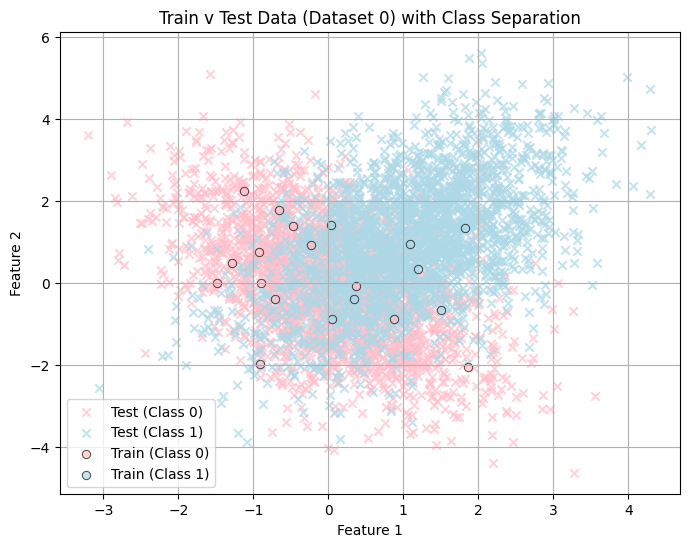

In [128]:
index = 0

# Visualization 
plt.figure(figsize=(8, 6))

# Test (X2): Class 0 (purple crosses) and Class 1 (green crosses)
plt.scatter(Xs_test[index][Bs_test[index] == 0, 0], Xs_test[index][Bs_test[index] == 0, 1], 
            c='pink', marker='x', label='Test (Class 0)', alpha=0.7)

plt.scatter(Xs_test[index][Bs_test[index] == 1, 0], Xs_test[index][Bs_test[index] == 1, 1], 
            c='lightblue', marker='x', label='Test (Class 1)', alpha=0.7)

# Train (X1): Class 0 (purple circles) and Class 1 (green circles)
plt.scatter(Xs_train[index][Bs_train[index] == 0, 0], Xs_train[index][Bs_train[index] == 0, 1], 
            c='pink',edgecolor='black', marker='o', label='Train (Class 0)', alpha=0.7,linewidths=0.7)

plt.scatter(Xs_train[index][Bs_train[index] == 1, 0], Xs_train[index][Bs_train[index] == 1, 1], 
            c='lightblue',edgecolor='black', marker='o', label='Train (Class 1)', alpha=0.7,linewidths=0.7)



plt.title(f"Train v Test Data (Dataset {index}) with Class Separation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

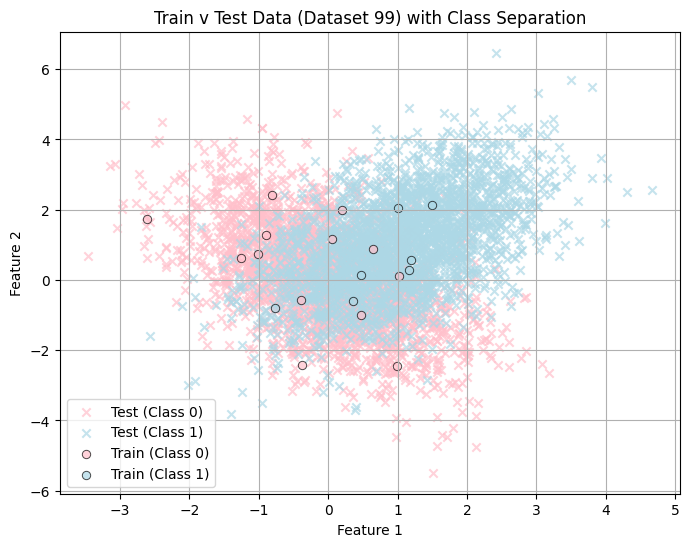

In [129]:
index = 99

# Visualization 
plt.figure(figsize=(8, 6))

# Test (X2): Class 0 (purple crosses) and Class 1 (green crosses)
plt.scatter(Xs_test[index][Bs_test[index] == 0, 0], Xs_test[index][Bs_test[index] == 0, 1], 
            c='pink', marker='x', label='Test (Class 0)', alpha=0.7)

plt.scatter(Xs_test[index][Bs_test[index] == 1, 0], Xs_test[index][Bs_test[index] == 1, 1], 
            c='lightblue', marker='x', label='Test (Class 1)', alpha=0.7)

# Train (X1): Class 0 (purple circles) and Class 1 (green circles)
plt.scatter(Xs_train[index][Bs_train[index] == 0, 0], Xs_train[index][Bs_train[index] == 0, 1], 
            c='pink',edgecolor='black', marker='o', label='Train (Class 0)', alpha=0.7,linewidths=0.7)

plt.scatter(Xs_train[index][Bs_train[index] == 1, 0], Xs_train[index][Bs_train[index] == 1, 1], 
            c='lightblue',edgecolor='black', marker='o', label='Train (Class 1)', alpha=0.7,linewidths=0.7)



plt.title(f"Train v Test Data (Dataset {index}) with Class Separation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

### Performance of the models!

In [130]:
errors_lda = np.zeros(n)
errors_qda = np.zeros(n)
errors_logistic = np.zeros(n)
errors_gnb = np.zeros(n)


for i in range(n):

    #Classifiers
    lda = LinearDiscriminantAnalysis()
    qda = QuadraticDiscriminantAnalysis()
    logistic = LogisticRegression(max_iter=1000)
    gnb = GaussianNB()

    # Train on train dataset 
    lda.fit(Xs_train[i], Bs_train[i])
    qda.fit(Xs_train[i], Bs_train[i])
    logistic.fit(Xs_train[i], Bs_train[i])
    gnb.fit(Xs_train[i], Bs_train[i])
    
    # Predictions
    prediction_lda = lda.predict(Xs_test[i])
    prediction_qda = qda.predict(Xs_test[i])
    prediction_logistic = logistic.predict(Xs_test[i])
    prediction_gnb = gnb.predict(Xs_test[i])
    
    # Error rates
    errors_lda[i] = 1 - accuracy_score(Bs_test[i], prediction_lda)
    errors_qda[i] = 1 - accuracy_score(Bs_test[i], prediction_qda)
    errors_logistic[i] = 1 - accuracy_score(Bs_test[i], prediction_logistic)
    errors_gnb[i] = 1 - accuracy_score(Bs_test[i], prediction_gnb)
    

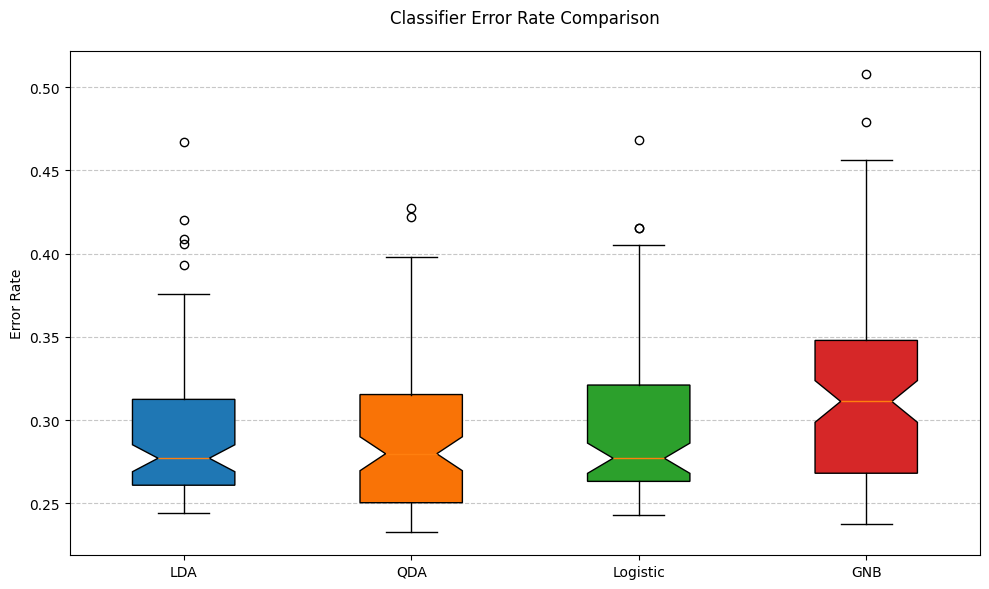

In [132]:
error_data = [errors_lda, errors_qda, errors_logistic, errors_gnb]
classifier_names = ['LDA', 'QDA', 'Logistic', 'GNB'] 

# Create boxplot 
plt.figure(figsize=(10, 6))
box = plt.boxplot(
    error_data,
    notch=True,
    patch_artist=True,  
    tick_labels=classifier_names
)

colors = ['#1f77b4', '#F97306', '#2ca02c', '#d62728']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Classifier Error Rate Comparison', pad=20)
plt.ylabel('Error Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


>  <span style='color:navy'> Linear Discriminant Analysis </span>

LDA no longer has the best performance as now the covariances differ across classes, so LDA is too restrictive by assuming a linear boundaries (where quadratic are better). So the results are now biased.

Though the relatively good performance of LDA, despite its incorrect assumption about shared covariances, is very likely due to the small training sample size that's ensuring a low variance thanks to fewer parameters to estimate ensuring more stable estimates.

>  <span style='color:green'> Logistic Regression </span>

It's still robust, but too simple.LG always fits a linear decision boundary,which is not the case here due to differing covariances.

As a result it's underfitting more now ( the median error rate went from 0.24 to 0.28 )

> <span style='color:orange'> Quadratic Discriminant Analysis </span>

Our best model in this scenario for the fact that it's dropping the shared covariance assumption. Estimates a separate covariance matrix per class so many more parameters than the LDA .

With only 20 samples, the estimates can be noisy. So even if it's the correct model, its higher variance can hurt.

It benefits from perfect inductive bias payed in the estimation of more parameters projected in the higher variance.

>  <span style='color:red'> Gaussian Naive Bayes </span>

Worst performance, again, especially with correlated features leading to higher variance.

It has the same issue as before for the assumption of feature independence which is now violated with the non-diagonal covariance, it can't model feature interactions, so is highly biased and underfits.


---
> 

## ▶️ Part 3: Real data (8 points)

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

## <span style='color:purple'> Let's analyze and preprocess the data first! </span> 

### <span style='color:navy'> We must first analyze where and how much data is missing.. <span/>

In [139]:
# Loading train and test data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [140]:
# Display size of data and column names
print("Train size:")
print(train.shape)

print("\nTest size :")
print(test.shape)

print(train.columns)
print(test.columns)

Train size:
(891, 12)

Test size :
(418, 11)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [141]:
# the first 5 rows
print("Train Data Preview:")
display(train.head())


Train Data Preview:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Interpretation:
>  <span style='color:red'> Cabin has missing values (NaN), most likely others do too. <span/>
    
>  <span style='color:red'> Name and Ticket are text fields—might need feature engineering.<span:>

Missing Values (train):
 [PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
IsTrain          0
dtype: int64]

Missing Values (test):
 [PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
IsTrain          0
dtype: int64]

Missing Values:
 [Age             263
Cabin          1014
Embarked          2
Fare              1
IsTrain           0
Name              0
Parch             0
PassengerId       0
Pclass            0
Sex               0
SibSp             0
Survived        418
Ticket            0
dtype: int64]


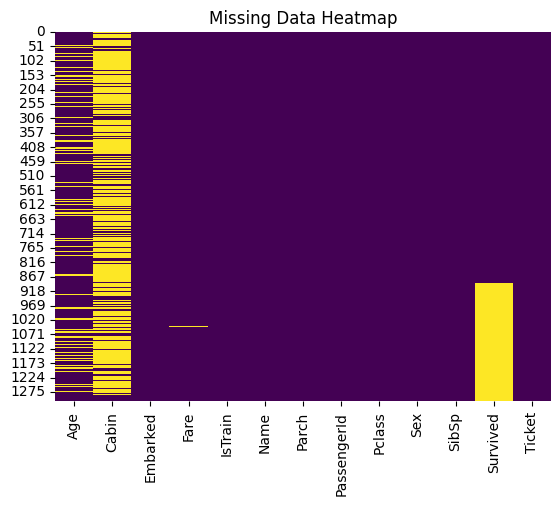

In [142]:
# Missing values summary
train['IsTrain'] = 1
test['IsTrain'] = 0
data=pd.concat([train, test], sort=True).reset_index(drop=True)

missing = [train.isnull().sum()]
print("Missing Values (train):\n", missing)

missing = [test.isnull().sum()]
print("\nMissing Values (test):\n", missing)

missing = [data.isnull().sum()]
print("\nMissing Values:\n", missing)

# Visualize missingness
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

In [143]:
data.describe()

,Age,Fare,IsTrain,Parch,PassengerId,Pclass,SibSp,Survived
count,1046.000000,1308.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,891.000000
mean,29.881138,33.295479,0.680672,0.385027,655.000000,2.294882,0.498854,0.383838
std,14.413493,51.758668,0.466394,0.865560,378.020061,0.837836,1.041658,0.486592
min,0.170000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,21.000000,7.895800,0.000000,0.000000,328.000000,2.000000,0.000000,0.000000
50%,28.000000,14.454200,1.000000,0.000000,655.000000,3.000000,0.000000,0.000000
75%,39.000000,31.275000,1.000000,0.000000,982.000000,3.000000,1.000000,1.000000
max,80.000000,512.329200,1.000000,9.000000,1309.000000,3.000000,8.000000,1.000000


### <span style='color:navy'> Is Age Missing at Random? A Rigorous Investigation </span>
---
To determine if Age is missing completely at random MCAR, missing at random MAR, or missing not at random MNAR, we’ll:

> <span style='color:navy'> Test statistical dependency between missingness and other features.</span>

> <span style='color:navy'> Visualize patterns of missingness.</span>

> <span style='color:navy'> And so choose the right imputation strategy based on findings.</span>


In [144]:
#a binary flag for missing Age
train['Age_NA'] = train['Age'].isnull().astype(int)

# Test correlation between Age_NA n other features
missing_corr = train.corr(numeric_only=True)['Age_NA'].sort_values(ascending=False)
print("Correlation with Age Missingness:\n", missing_corr)

Correlation with Age Missingness:
 Age_NA         1.000000
Pclass         0.172933
SibSp          0.018958
PassengerId   -0.020167
Survived      -0.092197
Fare          -0.100707
Parch         -0.124104
Age                 NaN
IsTrain             NaN
Name: Age_NA, dtype: float64


#### Interpretation:

> <span style='color:red'> Missingness correlates with Pclass/ Fare -> Not MCAR. </span>

> <span style='color:red'> Likely MAR since Missingness depends on observed data. </span>

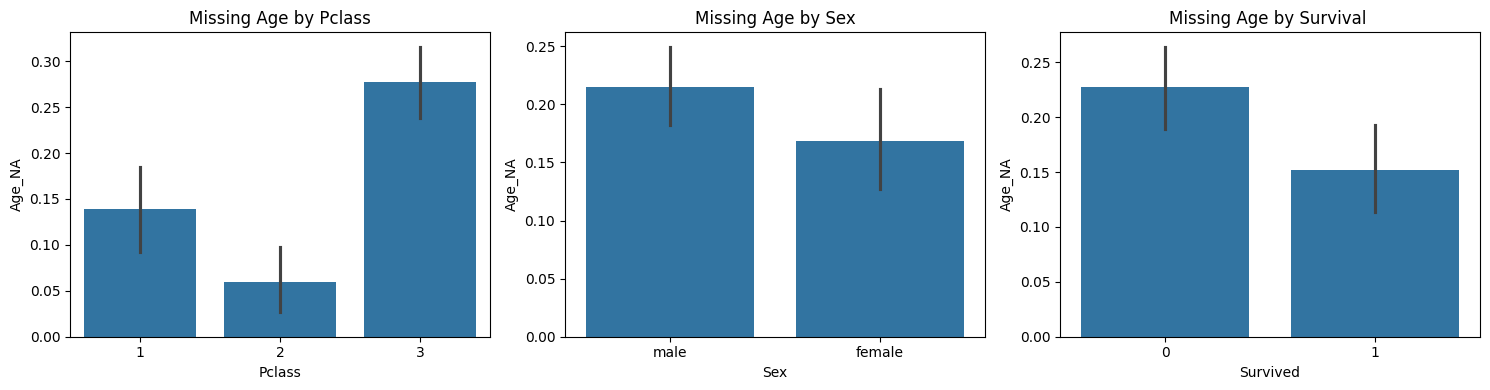

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(x='Pclass', y='Age_NA', data=train, ax=axes[0]).set_title('Missing Age by Pclass')
sns.barplot(x='Sex', y='Age_NA', data=train, ax=axes[1]).set_title('Missing Age by Sex')

train['Age_NA'] = train['Age'].isnull().astype(int)
sns.barplot(x='Survived', y='Age_NA', data=train, ax=axes[2]).set_title('Missing Age by Survival ')
plt.tight_layout()
plt.show()

#### Key Observations:

> For Pclass 3,   29% missing vs 12% for Pclass 1.

> For Sex/Survival , Bias is not as significant.

In [146]:
#Only used training data to avoid Data Leakage

# Features to predict Age missingness
X = train[['Pclass', 'Fare', 'Sex', 'SibSp', 'Parch']]
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)
y = train['Age_NA']

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Feature importance?
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance for Predicting Age Missingness:\n", importance)

Feature Importance for Predicting Age Missingness:
 Fare        0.751974
SibSp       0.087355
Pclass      0.080942
Parch       0.048858
Sex_male    0.030871
dtype: float64


#### Correlation:

> Weak linear ties: Pclass (0.2), Fare (-0.13).

> Suggests Pclass has a slightly stronger linear link to missingness than Fare.

#### Random Forest:

> Fare dominates (importance = 0.75), while Pclass is minor (=0.08).

> Reveals non-linear/interaction effects (e.g., low Fare + high Pclass → high missingness).

####  <span style='color:red'> Contradiction? </span>

> <span style='color:navy'> Pearson assumes linearity, but logistic relationships (in binary outcomes) are non-linear.</span>

> <span style='color:navy'> Also based on a real-world intuition, Fare is a direct measure of wealth; lower fares -poorer passengers means a higher chance of missing Age. Pclass is a proxy for wealth but less precise than Fare. </span>
> <span style='color:navy'> A 3rd-class passenger with Fare=20 is more likely to have missing Age than one with Fare=5. </span >

####  <span style='color:red'> So For Imputation we're using Fare as the primary grouping variable (not just Pclass)! </span>

In [173]:
#To manage in the pipeline
# Create fare bins and add as a new column
#data['FareBin'] = pd.qcut(train['Fare'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
#data['Age'] = data.groupby(
#    ['FareBin', 'Pclass'], observed=True
#)['Age'].transform(lambda x: x.fillna(x.median()))
#print(data['Age'].isnull().sum()) 

### <span style='color:navy'> Now that we know how to deal with missing Age values , let's deal with Cabin (77% Missing) </span>
---

#### So let's extract useful signal from partial data + flag missingness

77% of Cabin values are missing (687/891 in train set).

Missing Cabin by Class:
 Pclass
1    0.185185
2    0.913043
3    0.975560
Name: Cabin, dtype: float64


Text(0, 0.5, 'Missing Ratio')

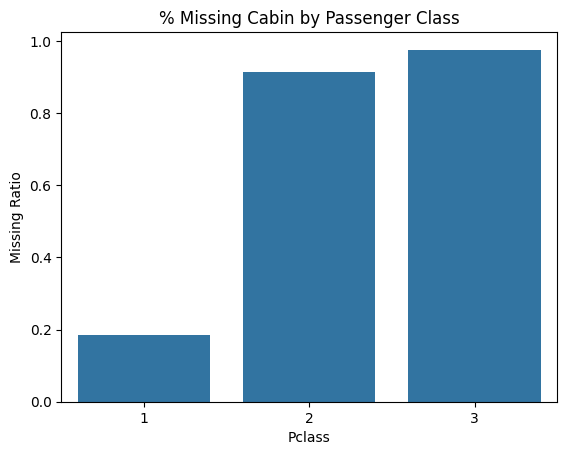

In [147]:
# Calculate missingness by Pclass
cabin_missing_by_class = train.groupby('Pclass')['Cabin'].apply(lambda x: x.isnull().mean())
print("Missing Cabin by Class:\n", cabin_missing_by_class)

sns.barplot(x=cabin_missing_by_class.index, y=cabin_missing_by_class.values)
plt.title("% Missing Cabin by Passenger Class")
plt.ylabel("Missing Ratio")

> Capture whether a passenger's cabin was recorded (regardless of the actual cabin number).

> The act of having a cabin recorded itself indicates privilege (linked to survival).

Text(0.5, 1.0, 'Survival Rate by Cabin Presence')

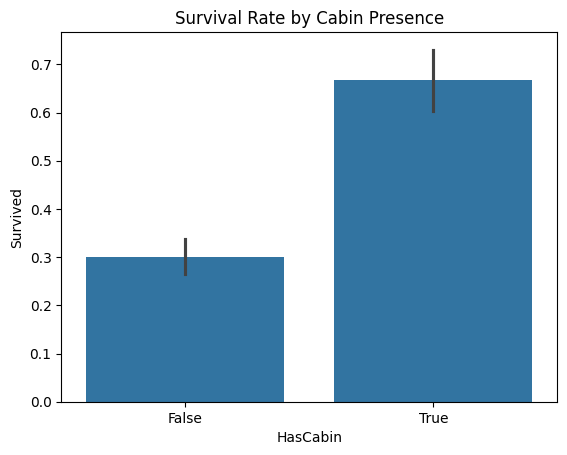

In [148]:
sns.barplot(x='HasCabin', y='Survived', data=train.assign(HasCabin=train['Cabin'].notna()))
plt.title("Survival Rate by Cabin Presence")

    Passengers with cabins (HasCabin=1) had ~66% survival vs. ~30% for others.

    So HasCabin is a strong survival predictor.

In [149]:
print("Cabin Data :")
display(train["Cabin"].head())

Cabin Data :


0     NaN
1     C85
2     NaN
3    C123
4     NaN
Name: Cabin, dtype: object

For passengers with cabin data, we extract the deck level (first letter of Cabin, ex: "C" from "C123").

Survival Rate by Deck:
 Deck
T    0.000000
A    0.466667
G    0.500000
C    0.593220
F    0.615385
B    0.744681
E    0.750000
D    0.757576
Name: Survived, dtype: float64


Text(0.5, 1.0, 'Survival Rate by Deck Level')

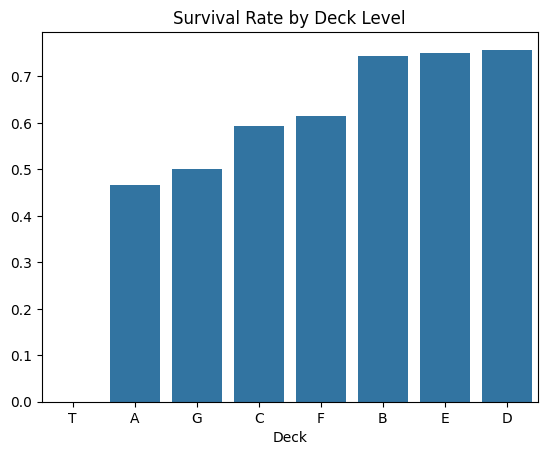

In [150]:
# Extract Deck
train['Deck'] = train['Cabin'].str[0]
deck_survival = train.groupby('Deck')['Survived'].mean().sort_values()

print("Survival Rate by Deck:\n", deck_survival)
sns.barplot(x=deck_survival.index, y=deck_survival.values)
plt.title("Survival Rate by Deck Level")

> Decks B, D, E have >70% survival rates.

> F, C, G, A cabins have progressively lower survival. 

In [151]:
train[train['Cabin'].str[0]=='T'].shape

(1, 15)

    Technically, Deck T has 0% survival rate in our data.

    But scientifically, n=1 is unsuffisant to create from it an independant category.

In [152]:
deck_T_passenger = train[train['Deck'] == 'T'][['Name', 'Survived', 'Pclass', 'Fare']]
print(deck_T_passenger)

                             Name  Survived  Pclass  Fare
339  Blackwell, Mr. Stephen Weart         0       1  35.5


>  #### Mr. Stephen Weart ; First class but low fare (35.5)
> #### Including T doesn't modify statistically the rate of survival for premium decks B, D, E.  
> #### Decision? Eliminate it to avoid overfitting.

In [153]:
# marking missing cabins AND Deck T as Unknown
train['Deck'] = np.where(
    train['Deck'].isin([None, 'T']),  
    'Unknown',                           
    train['Deck']                   
)

# Survivalbased grouping
deck_survival = train.groupby('Deck')['Survived'].mean()
deck_groups = {
    'B': 'Top', 'D': 'Top', 'E': 'Top',  
    'C': 'High', 'F': 'High',             
    'A': 'Mid', 'G': 'Mid'                
}

#Apply grouping
train['DeckGroup'] = train['Deck'].map(deck_groups).fillna('Unknown')

In [154]:
print("Unique DeckGroups:", train['DeckGroup'].unique())

Unique DeckGroups: ['Unknown' 'High' 'Top' 'Mid']


Text(0.5, 1.0, 'Deck Assignment Verification')

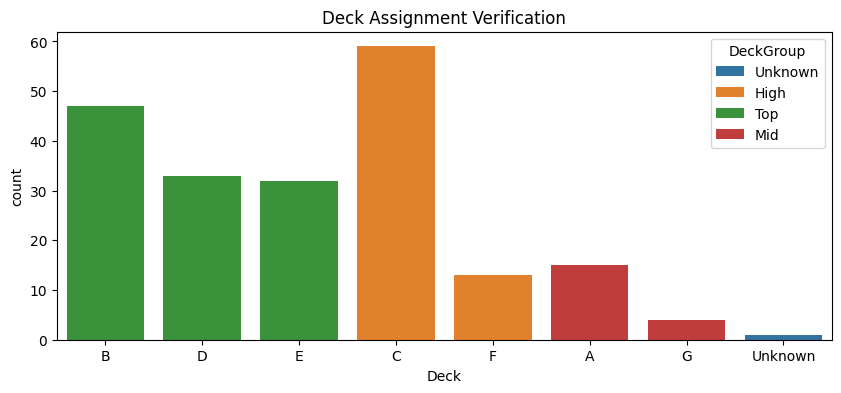

In [155]:
plt.figure(figsize=(10, 4))
sns.countplot(data=train, x='Deck', hue='DeckGroup', 
              order=['B','D','E','C','F','A','G','Unknown'])
plt.title("Deck Assignment")

#### Decks were grouped based on survival rates in the training set only. The 'Unknown' category consolidated:

>True missing values
>, Rare decks (like T)
>, Any decks not exhibiting statistically significant survival patterns

In [156]:
train.groupby('Deck')['Pclass'].value_counts() 

Deck     Pclass
A        1         15
B        1         47
C        1         59
D        1         29
         2          4
E        1         25
         2          4
         3          3
F        2          8
         3          5
G        3          4
Unknown  1          1
Name: count, dtype: int64

  >  Decks A/B/C/D were exclusively 1st class (except 4 passengers on D)

  >  Deck E had a mix of all classes (but mostly 1st)

  >  Decks F/G were primarily 2nd and 3rd class

In [157]:
#survival rates for these groups
print(train.groupby(['Deck','Pclass'])['Survived'].mean())

Deck     Pclass
A        1         0.466667
B        1         0.744681
C        1         0.593220
D        1         0.758621
         2         0.750000
E        1         0.720000
         2         0.750000
         3         1.000000
F        2         0.875000
         3         0.200000
G        3         0.500000
Unknown  1         0.000000
Name: Survived, dtype: float64


Instead of imputing fake deck letters (which would introduce noise), we:

    Preserved "missingness" as a signal via HasCabin and Deck='Unknown'.

    Created features only from trustworthy data (non-missing decks).

In [83]:
# Binary flags for high-survival decks
for deck in ['B', 'D', 'E']:
    train[f'Deck_{deck}'] = (train['Deck'] == deck).astype(int)  

# Interaction: Wealth (HasCabin) + Location (Deck_B/D/E)
train['Wealthy_Survivor_Zone'] = (train['HasCabin'] == 1) & (train['Deck'].isin(['B', 'D', 'E']))

Binary Flags for High Survival Decks: 
Creates separate True/False columns for decks B, D, and E (the safest decks).

    Lets the model separately detect if being on Deck B/D/E boosted survival.

    Passengers with missing cabins (Unknown) get 0 in all these columns.



    the Wealthy Survivor Zone : Combines privilege (having a cabin) and optimal location (safe decks).

    In the Titanic's layout:

        Decks B/D/E were close to lifeboats

        1st-class passengers here had priority access

    Deck_B/D/E Flags: Like separate "VIP Section" indicators for different parts of a concert venue.

    Wealthy_Survivor_Zone: Like a "VIP + Front Row" combo ticket—these passengers had double advantages.

### Exploring key Features

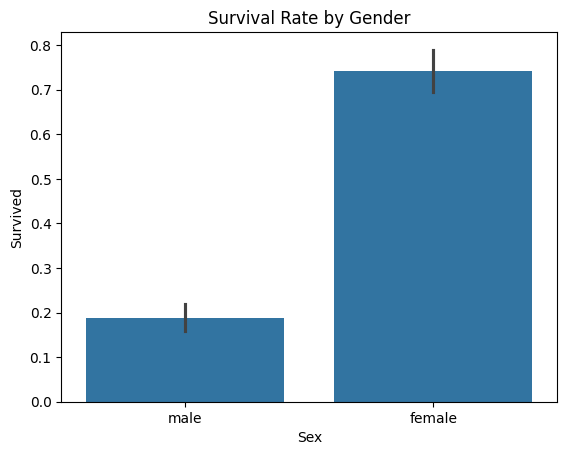

In [17]:
sns.barplot(x='Sex', y='Survived', data=train)
plt.title("Survival Rate by Gender")
plt.show()

#### Insight:
>  Female passengers survived much more often (~74% vs. ~19% for males).

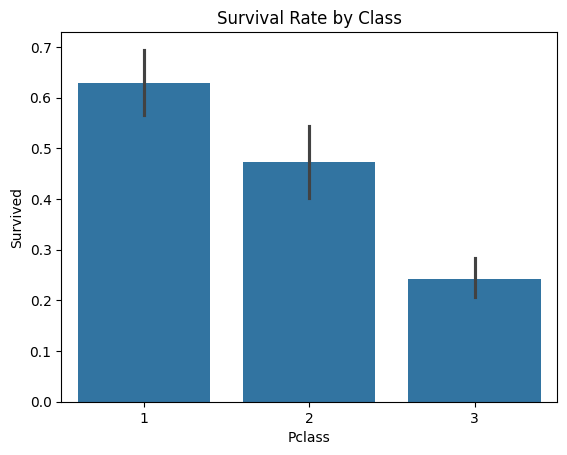

In [18]:
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title("Survival Rate by Class")
plt.show()

#### Insight:

> 1st class had the highest survival rate (~63%), while 3rd class had the lowest (~24%).

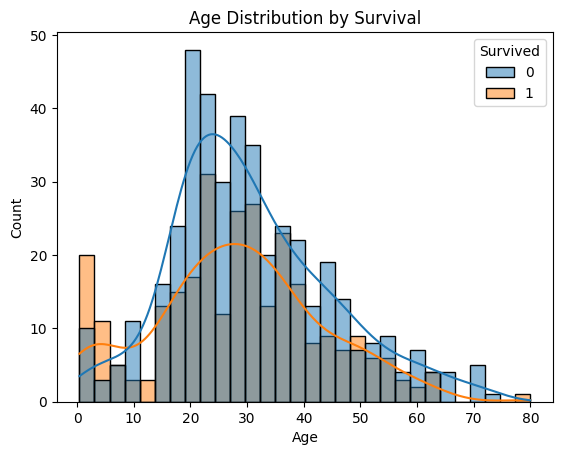

In [20]:
sns.histplot(data=train, x='Age', hue='Survived', bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

#### Insight:

> Children (Age < 10) had higher survival rates.
> Most passengers were aged 20-40.

#### Grouping people by family ? Frequency of tickets ?

In [ ]:
train['LastName'] = train['Name'].apply(lambda x: x.split(',')[0])

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?